#Descargando los datasets desde kaggle
Usamos kagglehub para bajar el dataset directamente al entorno, así no hay que subir los archivos a mano y cualquiera puede reproducir el notebook.

In [ ]:
!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("tuannguyenvananh/pokemon-dataset-with-team-combat")
print("Archivos descargados en:", path)

import os
for f in os.listdir(path):
    print(f)

100%|██████████| 276k/276k [00:00<00:00, 52.4MB/s]

Extracting files...
Archivos descargados en: /root/.cache/kagglehub/datasets/tuannguyenvananh/pokemon-dataset-with-team-combat/versions/6
pokemon.csv
combats.csv
team_combat.csv
pokemon_id_each_team.csv


#Cargando los datos y viendo la estructura de estos

In [ ]:
import pandas as pd
import numpy as np

DATA_DIR = path

# Cargar automáticamente todos los CSV que haya en la carpeta
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print("CSVs encontrados:", csv_files)

dfs = {}
for f in csv_files:
    name = f.replace('.csv', '')
    dfs[name] = pd.read_csv(os.path.join(DATA_DIR, f))
    print(f"\n--- {f} ---")
    print("Shape:", dfs[name].shape)
    print(dfs[name].head())

CSVs encontrados: ['pokemon.csv', 'combats.csv', 'team_combat.csv', 'pokemon_id_each_team.csv']

--- pokemon.csv ---
Shape: (800, 12)
   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65   
1  2        Ivysaur  Grass  Poison  60      62       63       80       80   
2  3       Venusaur  Grass  Poison  80      82       83      100      100   
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120   
4  5     Charmander   Fire     NaN  39      52       43       60       50   

   Speed  Generation  Legendary  
0     45           1      False  
1     60           1      False  
2     80           1      False  
3     80           1      False  
4     65           1      False  

--- combats.csv ---
Shape: (50000, 3)
   First_pokemon  Second_pokemon  Winner
0            266             298     298
1            702             701     701
2            191             668     

| Tabla | Filas x columnas | Qué representa |
|---|---|---|
| pokemon | 800 x 12 | Catálogo de Pokémon: tipos, stats base, generación y si es legendario |
| combats | 50 000 x 3 | Duelos **1v1**: quién peleó contra quién y quién ganó |
| pokemon_id_each_team | 100 x 7 | Los 6 Pokémon que forman cada uno de los 100 equipos |
| team_combat | 10 000 x 3 | Enfrentamientos **equipo vs equipo** y su resultado (**nuestra tabla objetivo**) |

#EDA
Empezamos por la tabla pokemon, que es la base de todas las variables que vamos a construir después.

In [ ]:
pokemon_df = dfs.get('pokemon')  # ajusta el nombre exacto si difiere

print("Información general:")
pokemon_df.info()

print("\nValores nulos por columna:")
print(pokemon_df.isnull().sum())

print("\nEstadísticas descriptivas (numéricas):")
display(pokemon_df.describe())

print("\nEstadísticas descriptivas (categóricas):")
display(pokemon_df.describe(include='object'))

print("\n% de pokemon con un solo tipo:", pokemon_df['Type 2'].isnull().mean()*100, "%")

# Duplicados
print("\nFilas duplicadas:", pokemon_df.duplicated().sum())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB

Valores nulos por columna:
#               0
Name            0
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,231.0844,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.0000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,200.7500,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,400.5000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,600.2500,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,800.0000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000



Estadísticas descriptivas (categóricas):


,Name,Type 1,Type 2
count,800,800,414
unique,800,18,18
top,Pumpkaboo Super Size,Water,Flying
freq,1,112,97



% de pokemon con un solo tipo: 48.25 %

Filas duplicadas: 0


#Distribuciones
Miramos cómo se reparten los 6 stats base, los tipos y los legendarios.

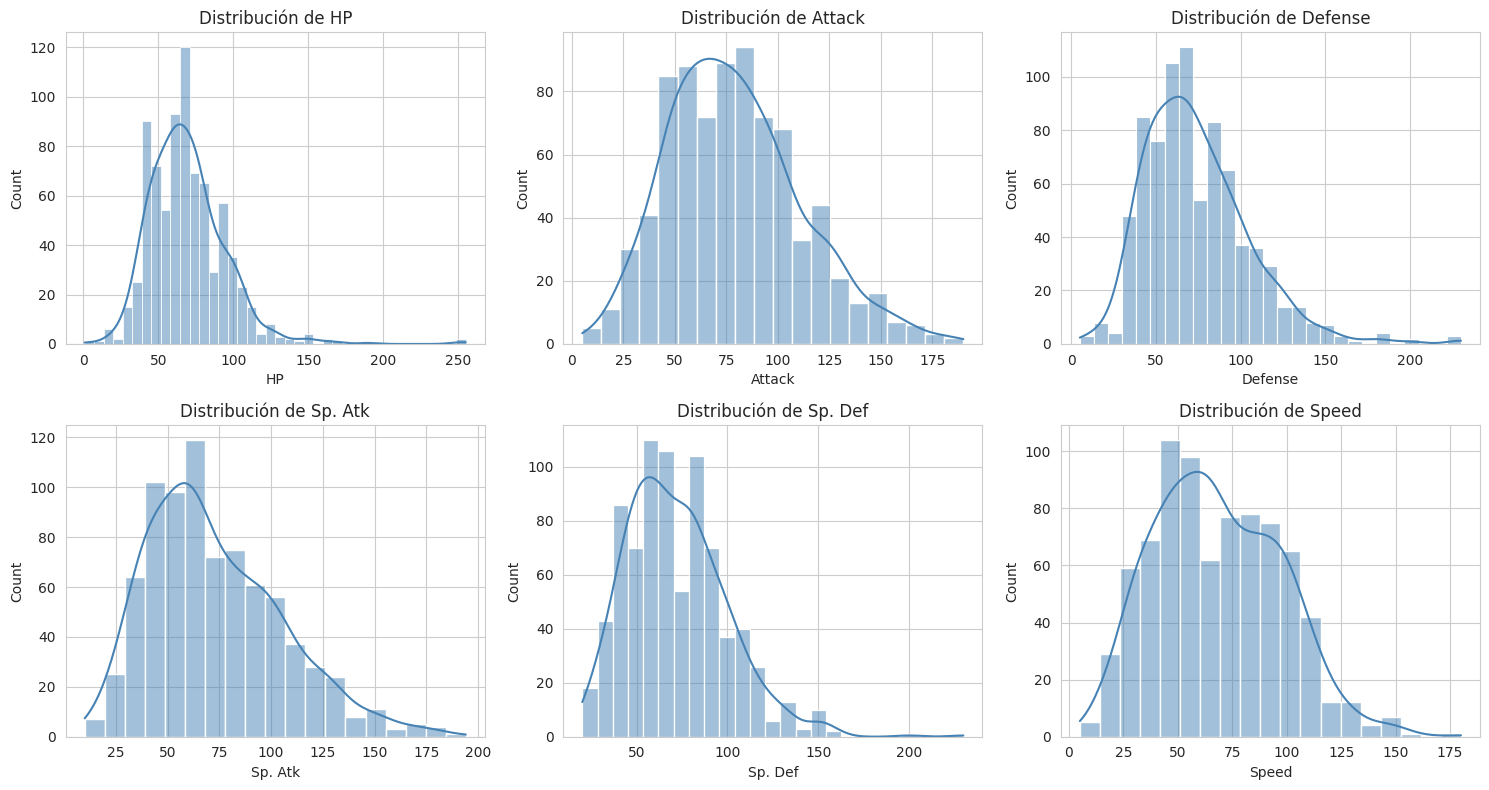

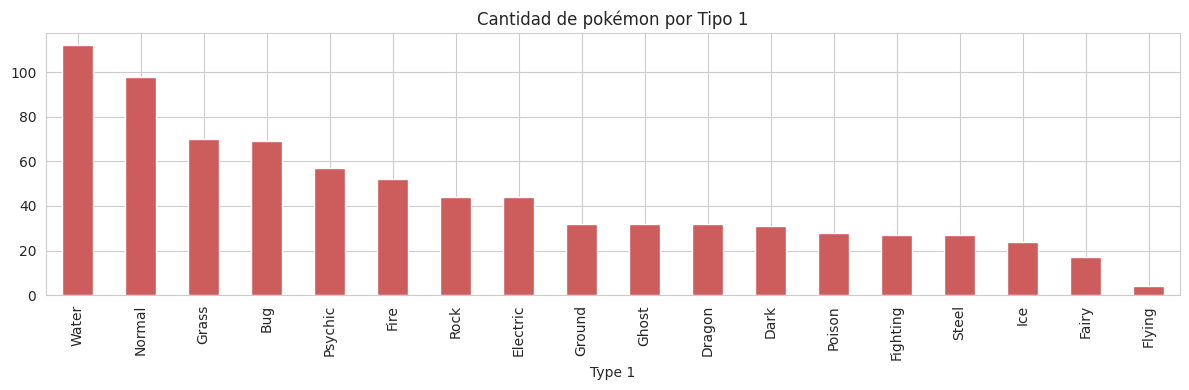

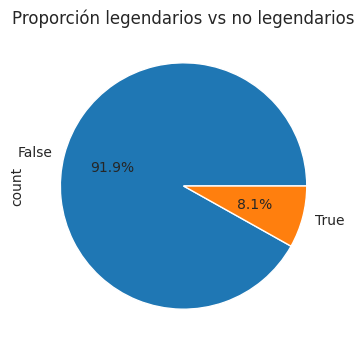

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

stat_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(stat_cols):
    sns.histplot(pokemon_df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

# Tipos primarios más comunes
plt.figure(figsize=(12,4))
pokemon_df['Type 1'].value_counts().plot(kind='bar', color='indianred')
plt.title('Cantidad de pokémon por Tipo 1')
plt.tight_layout()
plt.show()

# Legendarios
plt.figure(figsize=(4,4))
pokemon_df['Legendary'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporción legendarios vs no legendarios')
plt.show()

#Matriz de correlacion
Queremos ver qué stats se mueven juntos. Esta matriz es entre stats individuales de cada pokémon; más abajo haremos lo mismo con las diferencias entre equipos.

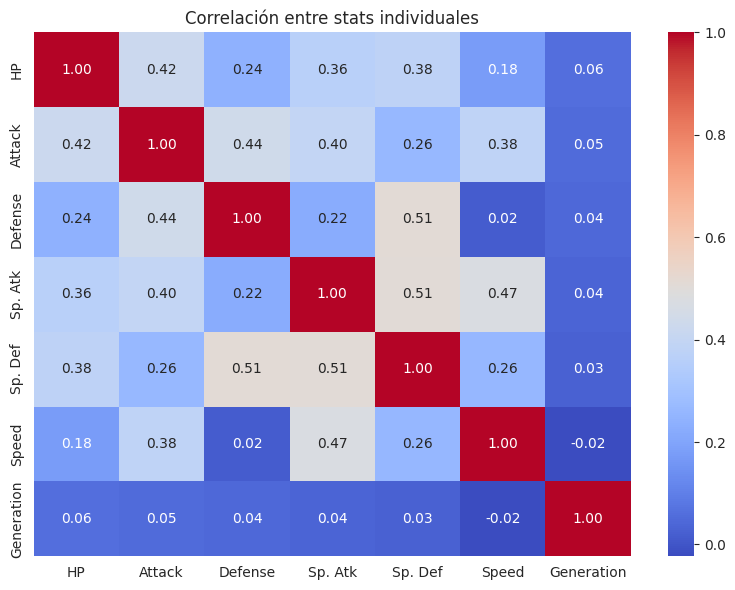

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(pokemon_df[stat_cols + ['Generation']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlación entre stats individuales")
plt.tight_layout()
plt.show()

#Más victorias 1v1
Miramos la tabla combats (duelos individuales) para tener una primera pista de qué características hacen ganar.

El First_pokemon gana el 47.2% de las veces


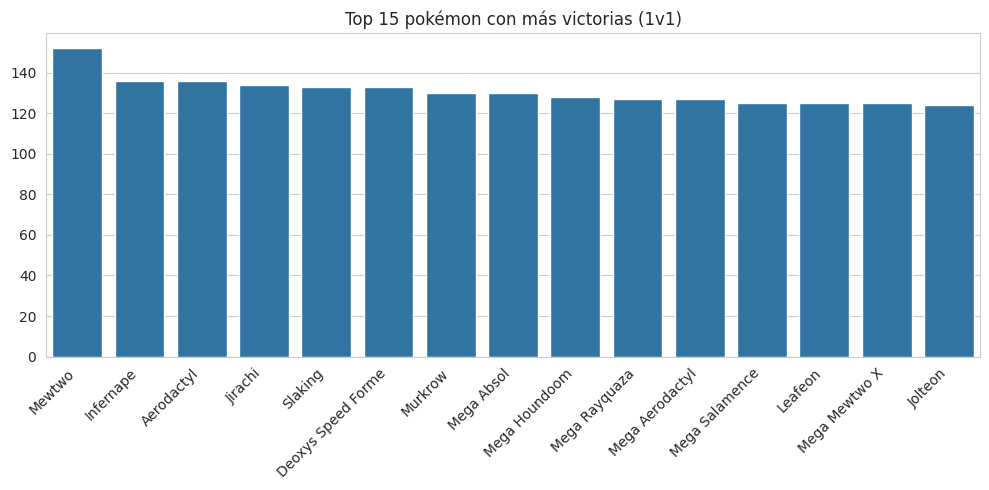

,Name,win_rate
#,,
155,Mega Aerodactyl,0.984496
513,Weavile,0.974790
704,Tornadus Therian Forme,0.968000
20,Mega Beedrill,0.966387
154,Aerodactyl,0.964539
477,Mega Lopunny,0.961240
727,Greninja,0.960630
717,Meloetta Pirouette Forme,0.959350
165,Mega Mewtwo Y,0.952000


In [ ]:
combats_df = dfs['combats']

# Balance: ¿gana más seguido el "First_pokemon" o el "Second_pokemon"?
first_wins = (combats_df['Winner'] == combats_df['First_pokemon']).mean()
print(f"El First_pokemon gana el {first_wins*100:.1f}% de las veces")

# Top 15 pokemon con más victorias
win_counts = combats_df['Winner'].value_counts().head(15)
win_names = pokemon_df.set_index('#').loc[win_counts.index, 'Name']
plt.figure(figsize=(10,5))
sns.barplot(x=win_names.values, y=win_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 pokémon con más victorias (1v1)')
plt.tight_layout()
plt.show()

# Total de combates por pokemon vs. % de victorias -> tasa de victoria real
appearances = pd.concat([combats_df['First_pokemon'], combats_df['Second_pokemon']]).value_counts()
win_rate = (combats_df['Winner'].value_counts() / appearances).fillna(0)
win_rate_df = pokemon_df.set_index('#').join(win_rate.rename('win_rate'))
display(win_rate_df.sort_values('win_rate', ascending=False)[['Name','win_rate']].head(10))

#Construccion features de equipo
Se buscan los 6 pokémon que lo componen y se calculan variables agregadas (suma y promedio de cada stat, cantidad de legendarios). Esto convierte "6 pokémon individuales" en "un perfil numérico de equipo".

In [ ]:
teams_df = dfs['pokemon_id_each_team']
team_combat_df = dfs['team_combat']

pokemon_cols = ['0','1','2','3','4','5']  # ids de los 6 pokemon del equipo
pokemon_stats = pokemon_df.set_index('#')[stat_cols + ['Legendary']]

def build_team_features(team_id):
    row = teams_df[teams_df['#'] == team_id]
    if row.empty:
        return None
    ids = row[pokemon_cols].values.flatten()
    stats = pokemon_stats.loc[ids]
    feats = {
        'team_id': team_id,
        'sum_HP': stats['HP'].sum(), 'mean_HP': stats['HP'].mean(),
        'sum_Attack': stats['Attack'].sum(), 'mean_Attack': stats['Attack'].mean(),
        'sum_Defense': stats['Defense'].sum(), 'mean_Defense': stats['Defense'].mean(),
        'sum_SpAtk': stats['Sp. Atk'].sum(), 'mean_SpAtk': stats['Sp. Atk'].mean(),
        'sum_SpDef': stats['Sp. Def'].sum(), 'mean_SpDef': stats['Sp. Def'].mean(),
        'sum_Speed': stats['Speed'].sum(), 'mean_Speed': stats['Speed'].mean(),
        'n_legendary': stats['Legendary'].sum(),
    }
    return feats

team_features = pd.DataFrame([build_team_features(tid) for tid in teams_df['#']])
display(team_features.head())

,team_id,sum_HP,mean_HP,sum_Attack,mean_Attack,sum_Defense,mean_Defense,sum_SpAtk,mean_SpAtk,sum_SpDef,mean_SpDef,sum_Speed,mean_Speed,n_legendary
0,1,315,52.500000,385,64.166667,342,57.000000,515,85.833333,475,79.166667,573,95.500000,0
1,2,386,64.333333,430,71.666667,480,80.000000,495,82.500000,420,70.000000,394,65.666667,0
2,3,498,83.000000,625,104.166667,442,73.666667,350,58.333333,533,88.833333,475,79.166667,0
3,4,468,78.000000,520,86.666667,434,72.333333,430,71.666667,405,67.500000,411,68.500000,0
4,5,360,60.000000,373,62.166667,348,58.000000,359,59.833333,366,61.000000,369,61.500000,0


#Merge features equpo con team_combat

In [ ]:
merged = team_combat_df.merge(team_features.add_suffix('_first'),
                               left_on='first', right_on='team_id_first') \
                        .merge(team_features.add_suffix('_second'),
                               left_on='second', right_on='team_id_second')

# Diferencias entre equipos (features fuertes para el modelo)
diff_cols_base = ['sum_HP','sum_Attack','sum_Defense','sum_SpAtk','sum_SpDef','sum_Speed','n_legendary']
for col in diff_cols_base:
    merged[f'diff_{col}'] = merged[f'{col}_first'] - merged[f'{col}_second']

display(merged.head())

,first,second,winner,team_id_first,sum_HP_first,mean_HP_first,sum_Attack_first,mean_Attack_first,sum_Defense_first,mean_Defense_first,...,sum_Speed_second,mean_Speed_second,n_legendary_second,diff_sum_HP,diff_sum_Attack,diff_sum_Defense,diff_sum_SpAtk,diff_sum_SpDef,diff_sum_Speed,diff_n_legendary
0,1,1,1,1,315,52.5,385,64.166667,342,57.0,...,573,95.500000,0,0,0,0,0,0,0,0
1,1,2,0,1,315,52.5,385,64.166667,342,57.0,...,394,65.666667,0,-71,-45,-138,20,55,179,0
2,1,3,1,1,315,52.5,385,64.166667,342,57.0,...,475,79.166667,0,-183,-240,-100,165,-58,98,0
3,1,4,0,1,315,52.5,385,64.166667,342,57.0,...,411,68.500000,0,-153,-135,-92,85,70,162,0
4,1,5,0,1,315,52.5,385,64.166667,342,57.0,...,369,61.500000,0,-45,12,-6,156,109,204,0


#EDA de combates por equipo

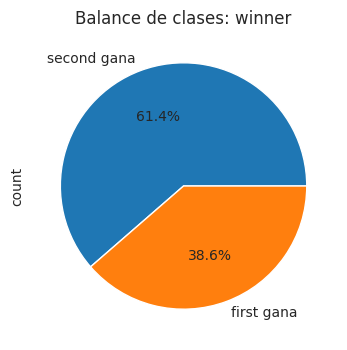

winner
1    0.6139
0    0.3861
Name: proportion, dtype: float64


,diff_sum_HP,diff_sum_Attack,diff_sum_Defense,diff_sum_SpAtk,diff_sum_SpDef,diff_sum_Speed,diff_n_legendary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
std,94.289469,109.244682,97.860853,103.600813,77.433194,87.07649,0.824662
min,-409.000000,-380.000000,-330.000000,-410.000000,-304.000000,-330.00000,-2.000000
25%,-57.000000,-73.000000,-65.000000,-69.000000,-48.250000,-55.00000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,57.000000,73.000000,65.000000,69.000000,48.250000,55.00000,0.000000
max,409.000000,380.000000,330.000000,410.000000,304.000000,330.00000,2.000000


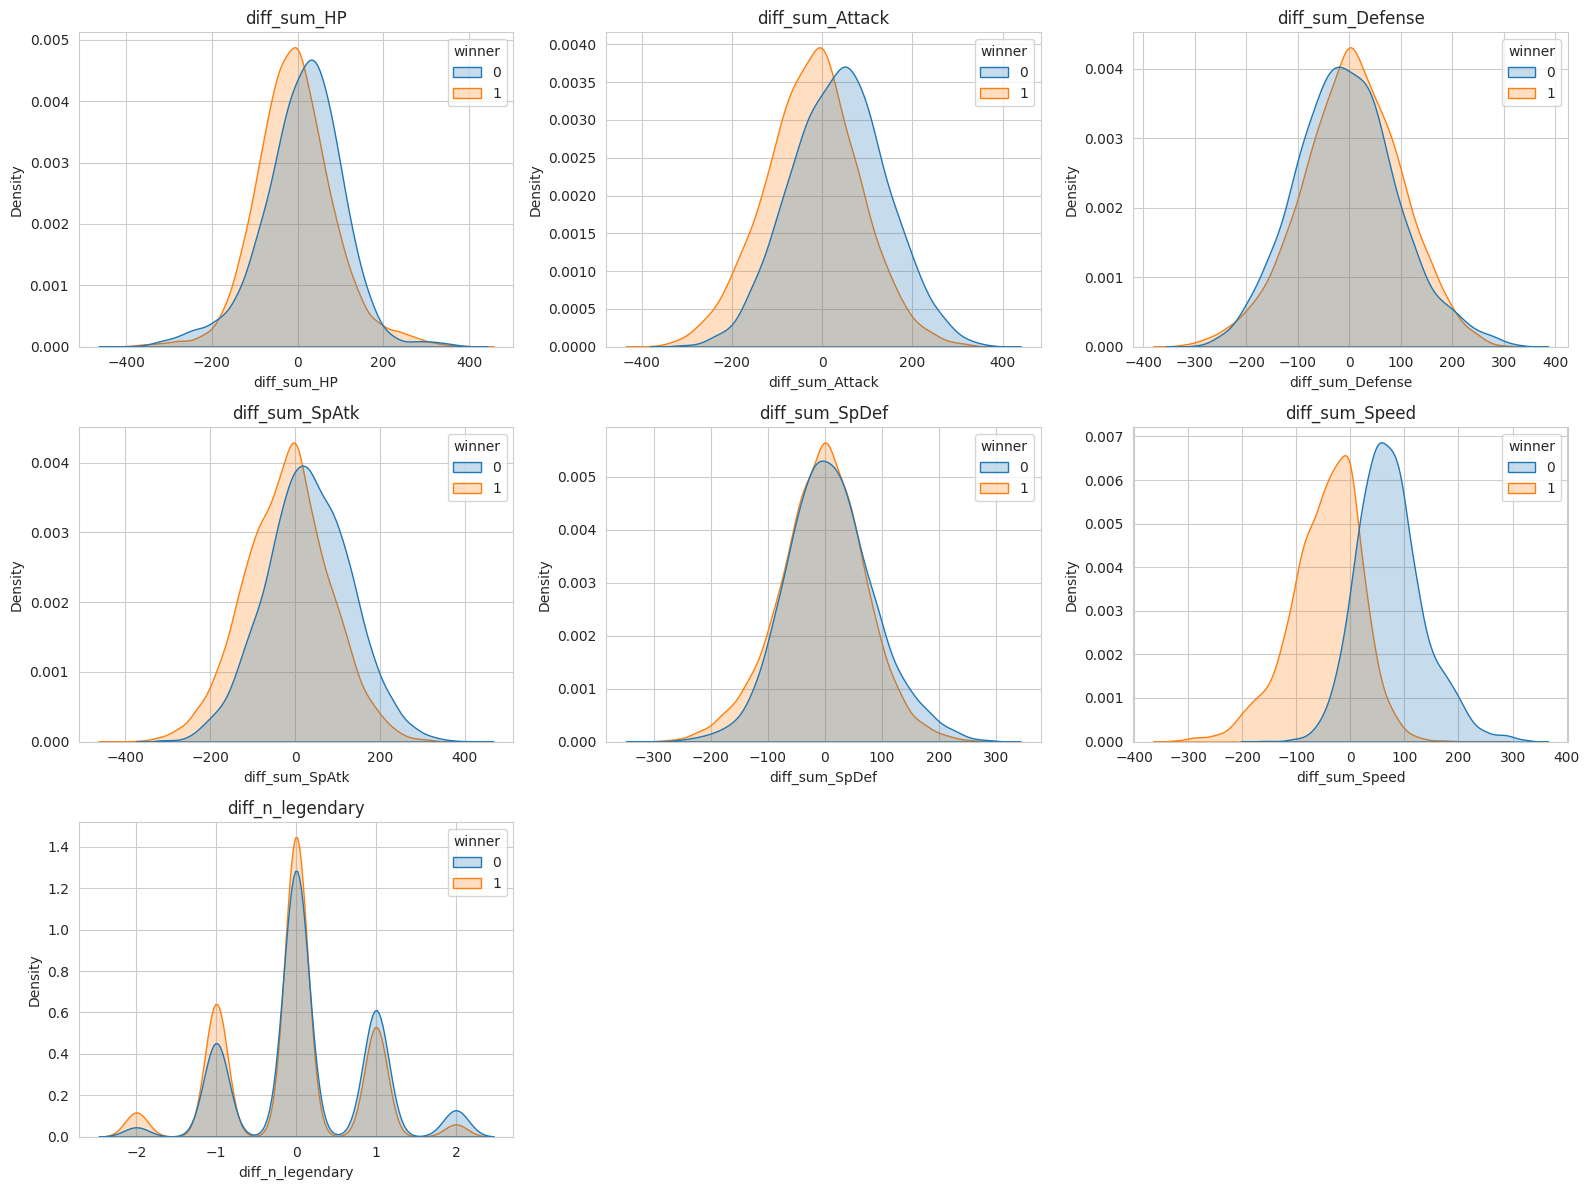


Correlación de cada diferencia de stat con 'winner':
winner              1.000000
diff_sum_Defense    0.045907
diff_sum_SpDef     -0.089124
diff_sum_HP        -0.092513
diff_n_legendary   -0.123546
diff_sum_SpAtk     -0.237240
diff_sum_Attack    -0.265302
diff_sum_Speed     -0.666477
Name: winner, dtype: float64


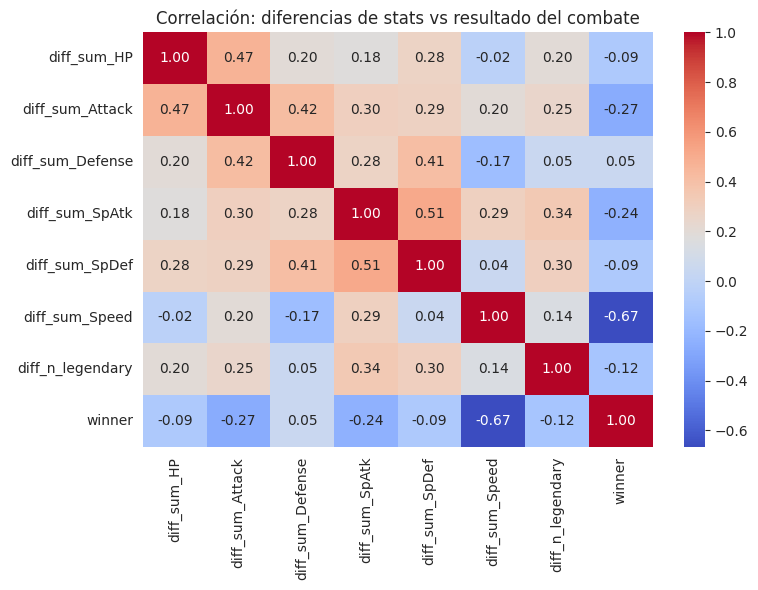

In [ ]:
# Balance de la clase objetivo (fundamental antes de modelar)
plt.figure(figsize=(4,4))
merged['winner'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['second gana','first gana'])
plt.title('Balance de clases: winner')
plt.show()
print(merged['winner'].value_counts(normalize=True))

# Estadísticas descriptivas de las diferencias
display(merged[[f'diff_{c}' for c in diff_cols_base]].describe())

# Distribución de las diferencias, separadas por resultado
diff_cols = [f'diff_{c}' for c in diff_cols_base]
fig, axes = plt.subplots(3, 3, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(diff_cols):
    sns.kdeplot(data=merged, x=col, hue='winner', ax=axes[i], fill=True, common_norm=False)
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Correlación de cada diferencia de stats con el resultado
corr_with_target = merged[diff_cols + ['winner']].corr()['winner'].sort_values(ascending=False)
print("\nCorrelación de cada diferencia de stat con 'winner':")
print(corr_with_target)

plt.figure(figsize=(8,6))
sns.heatmap(merged[diff_cols + ['winner']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlación: diferencias de stats vs resultado del combate")
plt.tight_layout()
plt.show()

#Deteccion outliers en stats

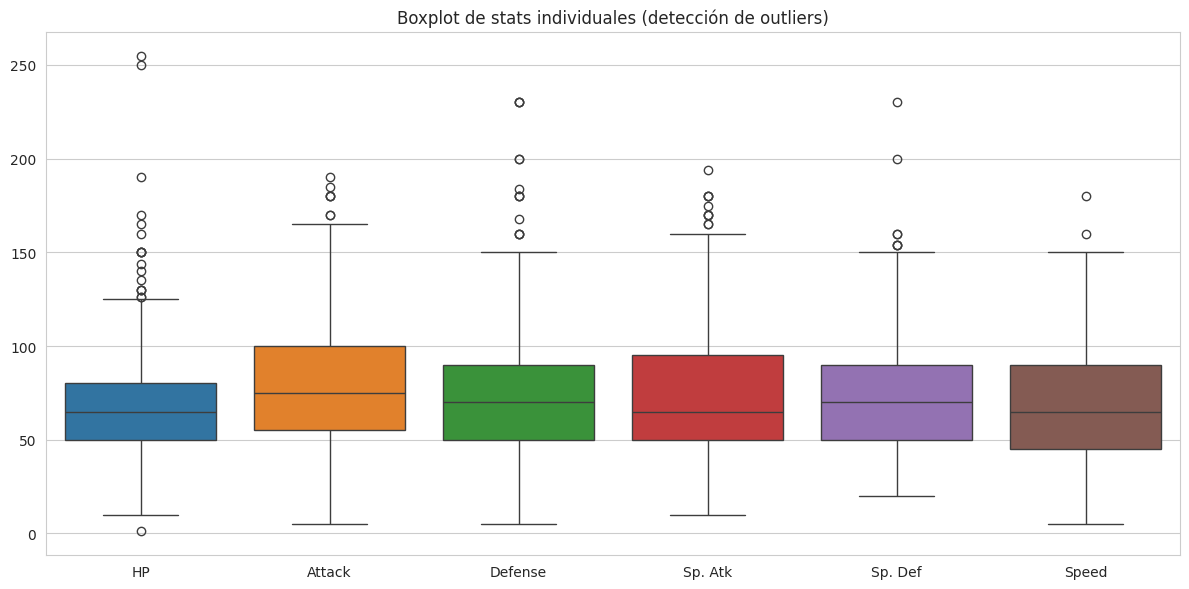

HP: 19 outliers (límites: 5.0 - 125.0)
Attack: 7 outliers (límites: -12.5 - 167.5)
Defense: 13 outliers (límites: -10.0 - 150.0)
Sp. Atk: 10 outliers (límites: -18.1 - 162.9)
Sp. Def: 7 outliers (límites: -10.0 - 150.0)
Speed: 2 outliers (límites: -22.5 - 157.5)


In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=pokemon_df[stat_cols])
plt.title('Boxplot de stats individuales (detección de outliers)')
plt.tight_layout()
plt.show()

# Outliers vía IQR para cada stat
for col in stat_cols:
    q1, q3 = pokemon_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = pokemon_df[(pokemon_df[col] < lower) | (pokemon_df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (límites: {lower:.1f} - {upper:.1f})")

#Distribucion de stats si es legendario o no
Los legendarios son pocos (8.1%) pero se supone que son más fuertes. Lo comprobamos.

/tmp/ipykernel_4820/4111733909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pokemon_df, x='Legendary', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_4820/4111733909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pokemon_df, x='Legendary', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_4820/4111733909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pokemon_df, x='Legendary', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_4820/4111733909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` i

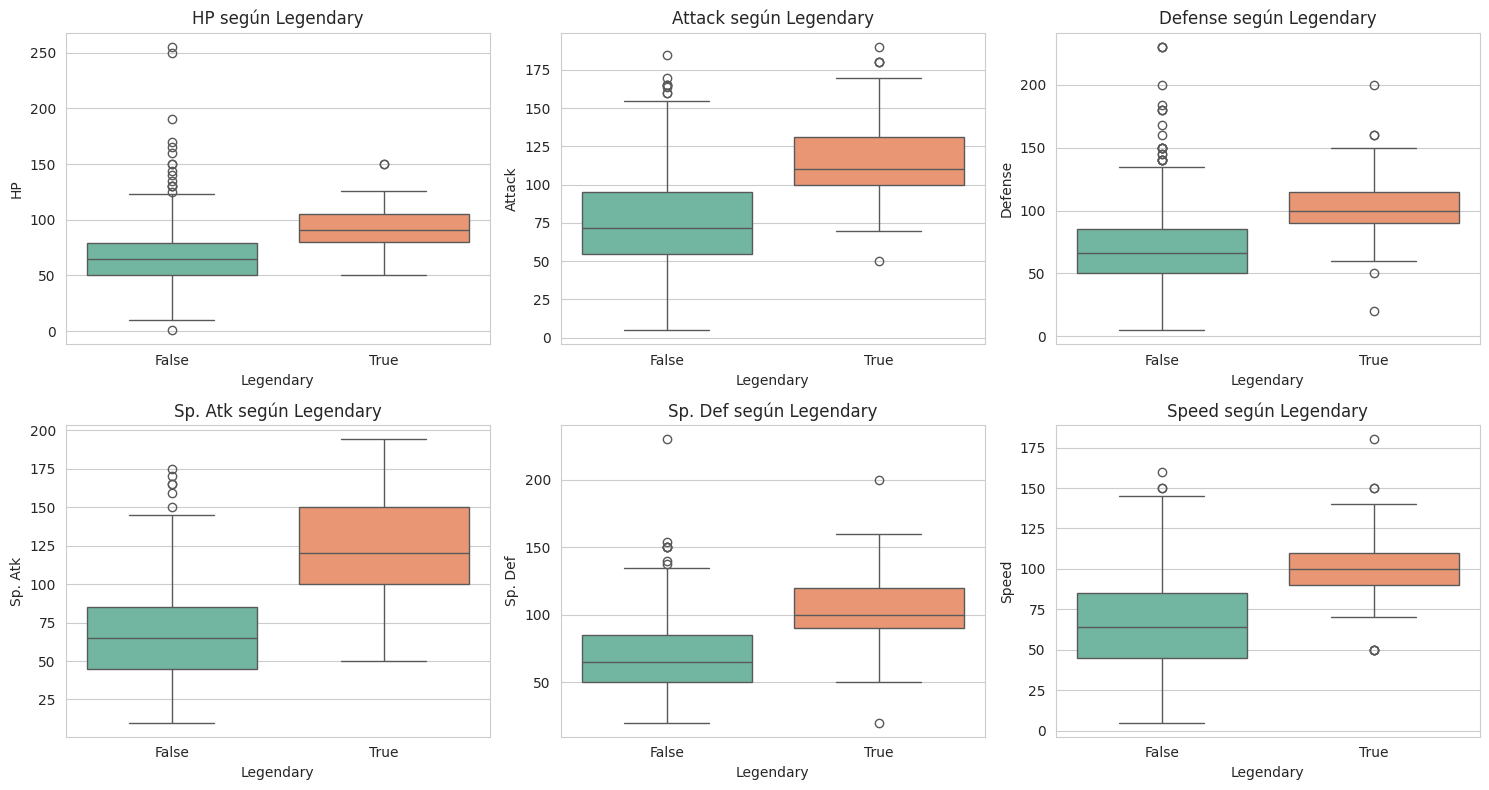

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Legendary,,,,,,
False,67.2,75.7,71.6,68.5,68.9,65.5
True,92.7,116.7,99.7,122.2,105.9,100.2


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
for i, col in enumerate(stat_cols):
    sns.boxplot(data=pokemon_df, x='Legendary', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} según Legendary')
plt.tight_layout()
plt.show()

# Diferencia de medias
display(pokemon_df.groupby('Legendary')[stat_cols].mean().round(1))

#Combinacion y tasa de victoria por tipos

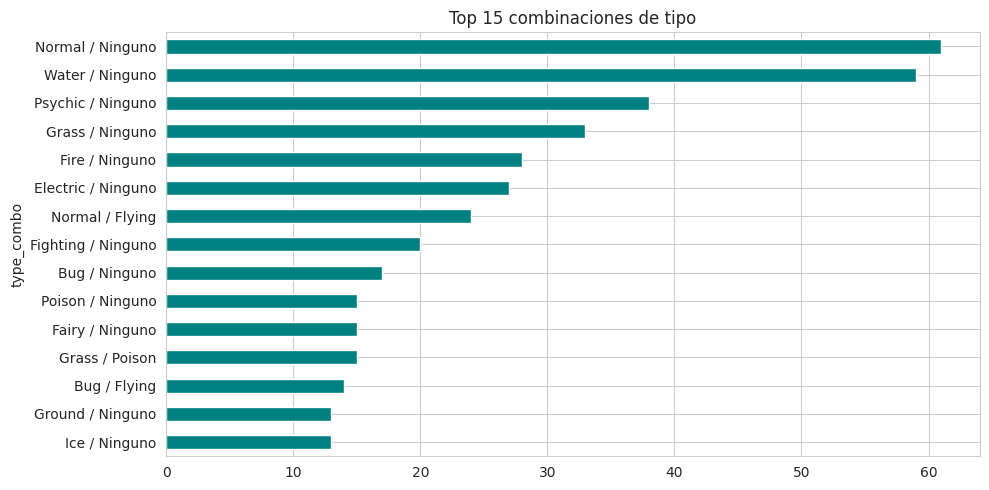

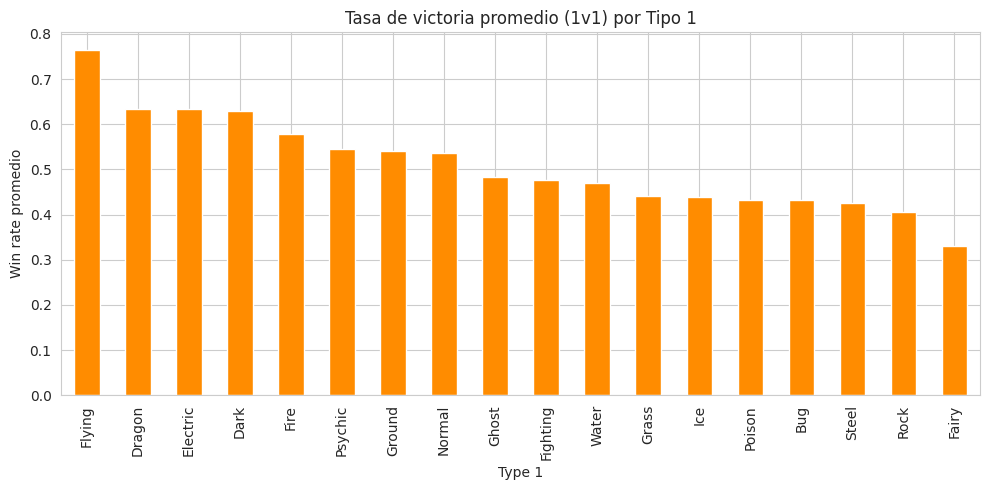

In [ ]:
# Combinaciones Type1+Type2 más comunes
pokemon_df['type_combo'] = pokemon_df['Type 1'] + ' / ' + pokemon_df['Type 2'].fillna('Ninguno')
plt.figure(figsize=(10,5))
pokemon_df['type_combo'].value_counts().head(15).plot(kind='barh', color='teal')
plt.title('Top 15 combinaciones de tipo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Tasa de victoria (1v1) promedio por Type 1
appearances = pd.concat([combats_df['First_pokemon'], combats_df['Second_pokemon']]).value_counts()
wins = combats_df['Winner'].value_counts()
win_rate_all = (wins / appearances).fillna(0).rename('win_rate')

type_winrate = pokemon_df.set_index('#')[['Type 1']].join(win_rate_all).groupby('Type 1')['win_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
type_winrate.plot(kind='bar', color='darkorange')
plt.title('Tasa de victoria promedio (1v1) por Tipo 1')
plt.ylabel('Win rate promedio')
plt.tight_layout()
plt.show()

#Cantidad de tipos distintos en un equipo

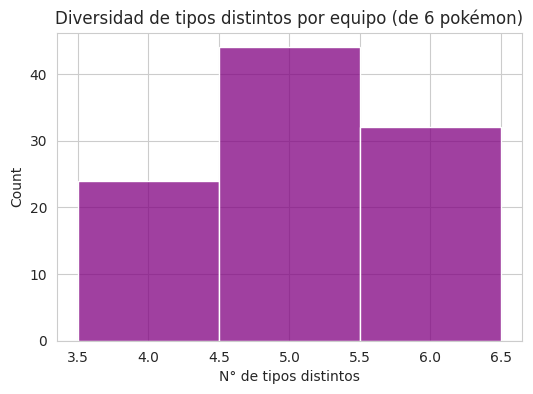

In [ ]:
type_lookup = pokemon_df.set_index('#')['Type 1']

def team_type_diversity(team_id):
    row = teams_df[teams_df['#'] == team_id]
    ids = row[pokemon_cols].values.flatten()
    types = type_lookup.loc[ids]
    return types.nunique()

team_features['type_diversity'] = team_features['team_id'].apply(team_type_diversity)

plt.figure(figsize=(6,4))
sns.histplot(team_features['type_diversity'], bins=range(1,8), discrete=True, color='purple')
plt.title('Diversidad de tipos distintos por equipo (de 6 pokémon)')
plt.xlabel('N° de tipos distintos')
plt.show()

#Verificacion si todas las variabels son relevantes

In [ ]:
from scipy import stats

print("Prueba de Mann-Whitney U (diferencia de distribuciones entre winner=1 y winner=0):\n")
for col in diff_cols:
    grupo_1 = merged.loc[merged['winner']==1, col]
    grupo_0 = merged.loc[merged['winner']==0, col]
    stat, p = stats.mannwhitneyu(grupo_1, grupo_0, alternative='two-sided')
    signif = "significativo" if p < 0.05 else "no significativo"
    print(f"{col:20s} p-valor={p:.2e} -> {signif}")

Prueba de Mann-Whitney U (diferencia de distribuciones entre winner=1 y winner=0):

diff_sum_HP          p-valor=1.86e-37 -> significativo
diff_sum_Attack      p-valor=7.15e-150 -> significativo
diff_sum_Defense     p-valor=3.39e-09 -> significativo
diff_sum_SpAtk       p-valor=4.64e-120 -> significativo
diff_sum_SpDef       p-valor=3.04e-13 -> significativo
diff_sum_Speed       p-valor=0.00e+00 -> significativo
diff_n_legendary     p-valor=6.20e-31 -> significativo


#Analisis multicolinealidad
Para detectar si las variables estan correlacionadas entre si

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = merged[diff_cols].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif_data.sort_values('VIF', ascending=False))

,feature,VIF
1,diff_sum_Attack,1.709854
3,diff_sum_SpAtk,1.624452
4,diff_sum_SpDef,1.610109
2,diff_sum_Defense,1.566776
0,diff_sum_HP,1.355981
5,diff_sum_Speed,1.289789
6,diff_n_legendary,1.222495


#Comprobación hipotesis
¿El equipo con más stats siempre gana? respuesta: no

In [ ]:
merged['diff_Total'] = (merged['sum_HP_first']+merged['sum_Attack_first']+merged['sum_Defense_first']+
                         merged['sum_SpAtk_first']+merged['sum_SpDef_first']+merged['sum_Speed_first']) - \
                        (merged['sum_HP_second']+merged['sum_Attack_second']+merged['sum_Defense_second']+
                         merged['sum_SpAtk_second']+merged['sum_SpDef_second']+merged['sum_Speed_second'])

naive_pred = (merged['diff_Total'] > 0).astype(int)
naive_accuracy = (naive_pred == merged['winner']).mean()
print(f"Accuracy de la regla ingenua 'gana quien tiene más stats totales': {naive_accuracy*100:.2f}%")

Accuracy de la regla ingenua 'gana quien tiene más stats totales': 36.37%


In [ ]:
# ¿Hay pares (first, second) repetidos o invertidos?
merged_pairs = merged[['first','second']].apply(lambda r: tuple(sorted(r)), axis=1)
print("Pares únicos de equipos que combatieron:", merged_pairs.nunique(), "de", len(merged), "combates")
print("Combates duplicados (mismo par exacto):", merged.duplicated(subset=['first','second']).sum())

# ¿Todos los team_id en team_combat existen en pokemon_id_each_team?
missing_teams = set(team_combat_df['first']).union(team_combat_df['second']) - set(teams_df['#'])
print("Team IDs en team_combat sin datos en pokemon_id_each_team:", len(missing_teams))

Pares únicos de equipos que combatieron: 5050 de 10000 combates
Combates duplicados (mismo par exacto): 0
Team IDs en team_combat sin datos en pokemon_id_each_team: 0


Conclusión general: el EDA muestra que el dataset está limpio (sin duplicados ni IDs faltantes), que el target está moderadamente desbalanceado (61/39), y que la variable más predictiva por lejos es la diferencia de velocidad entre equipos, seguida de ataque y ataque especial — mientras que la "fuerza total" del equipo, de forma ingenua, es un mal predictor.